In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter

In [2]:

DATA_PATH = r"../data/raw/ogyeiv2"

# 1. Проверка структуры
for split in ['train', 'test', 'valid']:
    images_dir = os.path.join(DATA_PATH, split, 'images')
    labels_dir = os.path.join(DATA_PATH, split, 'labels')
    n_images = len(os.listdir(images_dir)) if os.path.exists(images_dir) else 0
    n_labels = len(os.listdir(labels_dir)) if os.path.exists(labels_dir) else 0
    print(f"{split}: {n_images} изображений, {n_labels} label-файлов")


train: 3136 изображений, 3136 label-файлов
test: 672 изображений, 672 label-файлов
valid: 672 изображений, 672 label-файлов


In [3]:
# 2. Загружаем названия классов
df = pd.read_csv(os.path.join(DATA_PATH, "extracted_sentences.csv"), header=None)
print(f"\nКоличество названий: {len(df)}")
print("Первые 5 названий:")
for i in range(5):
    print(f"  class_{i}: {df.iloc[i, 0][:50]}...")


Количество названий: 112
Первые 5 названий:
  class_0: acc long 600 mg pezsgőtabletta...
  class_1: 	advil ultra forte lágy kapszula...
  class_2: akineton 2 mg tabletta...
  class_3: 	algoflex forte dolo 400 mg filmtabletta...
  class_4: algoflex rapid 400 mg lágy kapszula...


In [4]:
# 3. Посмотрим пример изображения и что в label
import random
labels_dir = os.path.join(DATA_PATH, 'train', 'labels')
sample_txt = random.choice(os.listdir(labels_dir))
with open(os.path.join(labels_dir, sample_txt), 'r') as f:
    numbers = f.read().strip().split()
    class_id = int(float(numbers[0]))
print(f"\nПример: {sample_txt} -> класс {class_id}")


Пример: milgamma_u_001.txt -> класс 62


Размер изображения: (3746, 2019)


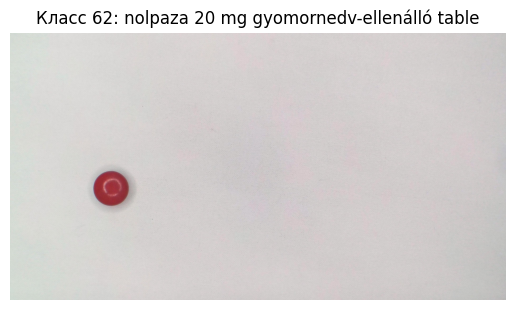

In [5]:
# 4. Покажем само изображение
img_file = sample_txt.replace('.txt', '.jpg')
img_path = os.path.join(DATA_PATH, 'train', 'images', img_file)
img = Image.open(img_path)
print(f"Размер изображения: {img.size}")
plt.imshow(img)
plt.title(f"Класс {class_id}: {df.iloc[class_id, 0][:40]}")
plt.axis('off')
plt.show()